# Task
Load and merge traffic stop data from "/content/drive/MyDrive/Policing Project/Datasets/il_chicago_2023_01_26.csv", community area boundaries from "/content/drive/MyDrive/Policing Project/Datasets/Boundaries_-_Community_Areas_20260207.csv", and socioeconomic indicators from "/content/drive/MyDrive/Policing Project/Datasets/Chicago Health Atlas Data Download - Community areas.csv". Perform a spatial join to attribute stops to neighborhoods, merge with the health atlas data, and save the final result as "/content/drive/MyDrive/Policing Project/Datasets/MergedData.csv", providing a summary of the new file's dimensions and columns.

## Load Datasets

### Subtask:
Load the three required datasets from Google Drive into pandas and geopandas DataFrames.


**Reasoning**:
Load the three required datasets using pandas and geopandas from the specified Google Drive paths and display their initial rows for verification.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import geopandas as gpd

In [3]:
def printTable(df, row_idx = 5):
  for col in df.columns:
      # handle short DataFrames safely
      if row_idx < len(df):
          val = df.iloc[row_idx][col]
      else:
          val = None

      print(f"{col} - {val}")

In [4]:
# 1. Load traffic stop data
traffic_stops_df = pd.read_csv('/content/drive/MyDrive/Policing Project/Datasets/il_chicago_2023_01_26.csv')

# 2. Load community area boundaries
# Using gpd.read_file() as requested, which can handle CSVs with geometry columns or spatial files
community_boundaries_gdf = gpd.read_file('/content/drive/MyDrive/Policing Project/Datasets/Boundaries_-_Community_Areas_20260207.csv')

# 3. Load socioeconomic indicators
socioeconomic_df = pd.read_csv('/content/drive/MyDrive/Policing Project/Datasets/Chicago Health Atlas Data Download - Community areas.csv')

/tmp/ipykernel_795/3679033716.py:2: DtypeWarning: Columns (12,14,15,20,21,22,23,24,25,27,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  traffic_stops_df = pd.read_csv('/content/drive/MyDrive/Policing Project/Datasets/il_chicago_2023_01_26.csv')


--- Traffic Stops Data ---
raw_row_number - 6
date - 2012-01-01
time - 01:00:00
location - nan
lat - nan
lng - nan
geocode_source - nan
beat - nan
district - nan
subject_age - 22.0
subject_race - black
subject_sex - male
officer_id_hash - nan
officer_age - nan
officer_race - nan
officer_sex - nan
officer_years_of_service - nan
unit - nan
type - vehicular
violation - DRIVING ON SUSPENDED LICENSE
arrest_made - True
citation_issued - nan
outcome - arrest
contraband_found - nan
contraband_drugs - nan
contraband_weapons - nan
contraband_alcohol - False
contraband_other - nan
search_conducted - False
search_person - False
search_vehicle - False
vehicle_make - nan
vehicle_model - nan
raw_race - BLACK
raw_driver_race - nan

--- Community Boundaries Data ---
the_geom - MULTIPOLYGON (((-87.64102430213292 41.954802805532566, -87.64101250186746 41.954761077017636, -87.64097666827071 41.954661587542425, -87.64095214384858 41.9545934968857, -87.64095043460787 41.95458875089718, -87.64095040051106 41

In [55]:
traffic_stops_df.shape[0]

2001379

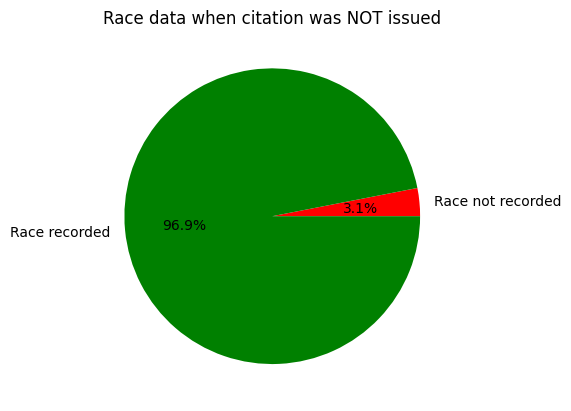

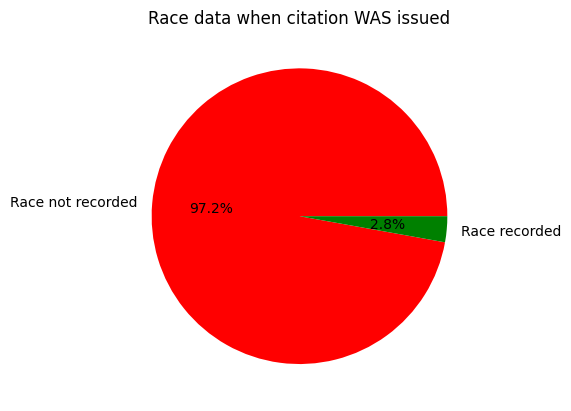

In [52]:
import matplotlib.pyplot as plt

# split data
missing_citation = traffic_stops_df[
    traffic_stops_df["citation_issued"].isna() | (traffic_stops_df["citation_issued"] == False)
]

nonmissing_citation = traffic_stops_df[
    traffic_stops_df["citation_issued"].notna() & (traffic_stops_df["citation_issued"] != False)
]

# counts
missing_race_missing = missing_citation["subject_race"].isna().sum()
missing_race_present = missing_citation["subject_race"].notna().sum()

nonmissing_race_missing = nonmissing_citation["subject_race"].isna().sum()
nonmissing_race_present = nonmissing_citation["subject_race"].notna().sum()

labels = ["Race not recorded", "Race recorded"]
colors = ["red", "green"]

# pie chart 1
plt.figure()
plt.pie(
    [missing_race_missing, missing_race_present],
    labels=labels,
    colors=colors,
    autopct="%1.1f%%"
)
plt.title("Race data when citation was NOT issued")
plt.show()

# pie chart 2
plt.figure()
plt.pie(
    [nonmissing_race_missing, nonmissing_race_present],
    labels=labels,
    colors=colors,
    autopct="%1.1f%%"
)
plt.title("Race data when citation WAS issued")
plt.show()

In [5]:
# Clean
traffic_stops_df = traffic_stops_df[
    (traffic_stops_df['lat'].notna()) &
    (traffic_stops_df['lng'].notna())
].copy()

# Convert to numeric in case they were read as strings
traffic_stops_df['lat'] = pd.to_numeric(traffic_stops_df['lat'], errors='coerce')
traffic_stops_df['lng'] = pd.to_numeric(traffic_stops_df['lng'], errors='coerce')

traffic_stops_df = traffic_stops_df.dropna(subset=['lat','lng'])
printTable(traffic_stops_df)

raw_row_number - 10
date - 2012-01-01
time - 01:00:00
location - 11000 HARLEM AVENUE S
lat - 41.691684915000046
lng - -87.79759360899997
geocode_source - SU
beat - nan
district - nan
subject_age - 22.0
subject_race - white
subject_sex - male
officer_id_hash - f6b9c2fe4d
officer_age - nan
officer_race - white
officer_sex - male
officer_years_of_service - 1.0
unit - nan
type - vehicular
violation - IVC - DRIVING MORE THAN 30 MPH BUT LESS THAN 40 MPH
arrest_made - True
citation_issued - nan
outcome - arrest
contraband_found - nan
contraband_drugs - nan
contraband_weapons - nan
contraband_alcohol - False
contraband_other - nan
search_conducted - False
search_person - False
search_vehicle - False
vehicle_make - nan
vehicle_model - nan
raw_race - WHITE
raw_driver_race - nan


In [6]:
# Convert traffic stops to GeoDataFrame
traffic_stops_gdf = gpd.GeoDataFrame(
    traffic_stops_df,
    geometry=gpd.points_from_xy(traffic_stops_df['lng'], traffic_stops_df['lat']),
    crs="EPSG:4326"   # WGS84 lat/lon
)

printTable(traffic_stops_gdf)

raw_row_number - 10
date - 2012-01-01
time - 01:00:00
location - 11000 HARLEM AVENUE S
lat - 41.691684915000046
lng - -87.79759360899997
geocode_source - SU
beat - nan
district - nan
subject_age - 22.0
subject_race - white
subject_sex - male
officer_id_hash - f6b9c2fe4d
officer_age - nan
officer_race - white
officer_sex - male
officer_years_of_service - 1.0
unit - nan
type - vehicular
violation - IVC - DRIVING MORE THAN 30 MPH BUT LESS THAN 40 MPH
arrest_made - True
citation_issued - nan
outcome - arrest
contraband_found - nan
contraband_drugs - nan
contraband_weapons - nan
contraband_alcohol - False
contraband_other - nan
search_conducted - False
search_person - False
search_vehicle - False
vehicle_make - nan
vehicle_model - nan
raw_race - WHITE
raw_driver_race - nan
geometry - POINT (-87.79759360899997 41.691684915000046)


In [7]:
# Fix community boundaries geometry
from shapely import wkt

community_boundaries_gdf['geometry'] = community_boundaries_gdf['the_geom'].apply(wkt.loads)
community_boundaries_gdf = gpd.GeoDataFrame(community_boundaries_gdf, geometry='geometry')

# Set CRS (Chicago open data boundaries are also WGS84)
community_boundaries_gdf.set_crs(epsg=4326, inplace=True)

printTable(community_boundaries_gdf)

the_geom - MULTIPOLYGON (((-87.64102430213292 41.954802805532566, -87.64101250186746 41.954761077017636, -87.64097666827071 41.954661587542425, -87.64095214384858 41.9545934968857, -87.64095043460787 41.95458875089718, -87.64095040051106 41.95458864037436, -87.64089103844454 41.95439731289194, -87.64084524793203 41.95424972731757, -87.6408199509196 41.954227323316076, -87.64081149188247 41.95421983164456, -87.64080886046415 41.95421605236422, -87.64078151816756 41.95417678630166, -87.64076035282518 41.95411932469774, -87.64074019680832 41.95406460103801, -87.64071372533175 41.954003657121085, -87.6406698093118 41.95389606836762, -87.64066813504104 41.95389196692557, -87.6406480210949 41.95380278117872, -87.64063859819028 41.95376100000359, -87.64061328317106 41.95369153101834, -87.6406106015751 41.95368417270765, -87.64059618432951 41.95364460917526, -87.64059164162107 41.95361244982352, -87.64048680860238 41.95360062442254, -87.64045720646926 41.95351792137751, -87.64042760441137 41.9

In [8]:
# Spatial join: assign each stop a community area
if community_boundaries_gdf.crs is None:
    community_boundaries_gdf = community_boundaries_gdf.set_crs("EPSG:4326")
if traffic_stops_gdf.crs != community_boundaries_gdf.crs:
    traffic_stops_gdf = traffic_stops_gdf.to_crs(community_boundaries_gdf.crs)

# Keep only needed boundary columns
boundaries = community_boundaries_gdf[['AREA_NUMBE', 'COMMUNITY', 'geometry']].copy()
boundaries = boundaries.rename(columns={
    'AREA_NUMBE': 'community_area_id',
    'COMMUNITY': 'community_area_name'
})

# Spatial join
traffic_with_area = gpd.sjoin(
    traffic_stops_gdf,
    boundaries,
    how='left',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Optional: enforce numeric community_area_id
traffic_with_area['community_area_id'] = pd.to_numeric(
    traffic_with_area['community_area_id'],
    errors='coerce'
)

printTable(traffic_with_area)

raw_row_number - 10
date - 2012-01-01
time - 01:00:00
location - 11000 HARLEM AVENUE S
lat - 41.691684915000046
lng - -87.79759360899997
geocode_source - SU
beat - nan
district - nan
subject_age - 22.0
subject_race - white
subject_sex - male
officer_id_hash - f6b9c2fe4d
officer_age - nan
officer_race - white
officer_sex - male
officer_years_of_service - 1.0
unit - nan
type - vehicular
violation - IVC - DRIVING MORE THAN 30 MPH BUT LESS THAN 40 MPH
arrest_made - True
citation_issued - nan
outcome - arrest
contraband_found - nan
contraband_drugs - nan
contraband_weapons - nan
contraband_alcohol - False
contraband_other - nan
search_conducted - False
search_person - False
search_vehicle - False
vehicle_make - nan
vehicle_model - nan
raw_race - WHITE
raw_driver_race - nan
geometry - POINT (-87.79759360899997 41.691684915000046)
community_area_id - nan
community_area_name - nan


In [9]:
socioeconomic_df.head(5)

,Layer,Name,GEOID,Longitude,Latitude,CZD_2024,CZM_2024,CZU_2012-2016,CZV_2024,HCSNVP_2023-2024,...,HCSTLG_2023-2024,HCSTLGP_2023-2024,EDX_2020-2024,HDX_2020-2024,INC_2020-2024,POV_2020-2024,FOR_2020-2024,LEQ_2020-2024,PCT-W_2020-2024,POP_2020-2024
0,(Indicator name),NaN,NaN,NaN,NaN,"Drug abuse (crimes), 2024","Major crime (crimes), 2024","Public crime (crimes), 2012-2016","Violent crime (crimes), 2024",Perceived neighborhood violence rate (% of adu...,...,"Trust in local government (counts of adults), ...","Trust in local government rate (% of adults), ...","Economic Diversity Index, 2020-2024","Hardship Index (score), 2020-2024","Median household income, 2020-2024","Poverty rate (% of residents), 2020-2024","Foreign born (% of residents), 2020-2024","Limited English proficiency (% of residents), ...","Demographics, White (Non-Hispanic) (% of resid...","Population (residents), 2020-2024"
1,(Definition),NaN,NaN,NaN,NaN,Drug abuse crimes. Drug abuse is defined as th...,"The most serious offenses, also known as index...",Public crimes. Public crimes include violent c...,"Crimes related to violence. Includes homicide,...",Percent of adults who reported violence occurs...,...,Number of adults who reported they trust their...,Percent of adults who reported they trust thei...,The Economic Diversity Index measures the prob...,The Hardship Index is a composite score reflec...,Income in the past 12 months.,Percent of residents in families that are in p...,Percent of residents who were not U.S. citizen...,Percentage of residents 5 years and older who ...,Percent of residents within each demographic g...,Average population over the time period.
2,(Citation),NaN,NaN,NaN,NaN,Crime data portal,Crime data portal,Crime data portal,Crime data portal,"Chicago Department of Public Health, Healthy C...",...,"Chicago Department of Public Health, Healthy C...","Chicago Department of Public Health, Healthy C...",American Community Survey (Table B17026 (Calcu...,American Community Survey (Calculated by Metopio),American Community Survey (Table B19013),American Community Survey (Table B17001),American Community Survey (Table B05002),American Community Survey (Table B16004),American Community Survey (Table B01001),American Community Survey (ACS: Table B01001; ...
3,---,---,---,---,---,---,---,---,---,---,...,---,---,---,---,---,---,---,---,---,---
4,Community area,Rogers Park,1,-87.67017100,42.00963000,52.4309407768988,1760.9071977353642,495.0,298.2031417692183,34.801957182,...,19500.0,36.961025227,0.7348037073331665,52.924703695294006,63293.40698066556,17.476964689546712,25.38058398390836,16.137010439363735,44.90256848483232,54023.51404694976


In [10]:
import re

# Drop columns you do not want
socioeconomic_clean = socioeconomic_df.drop(
    columns=['Layer', 'GEOID', 'Longitude', 'Latitude'],
    errors='ignore'
)

desc_row = socioeconomic_clean.iloc[0]

new_cols = {}
for col in socioeconomic_clean.columns:
    if col == "Name":
        new_cols[col] = "community_area_name"
        continue

    desc = str(desc_row[col])
    desc = re.sub(r"\s*\(.*?\)", "", desc)
    desc = desc.split(",")[0]
    desc = desc.lower().strip().replace(" ", "_")

    new_cols[col] = desc

socioeconomic_clean = socioeconomic_clean.rename(columns=new_cols)

# Standardize names
socioeconomic_clean["community_area_name"] = (
    socioeconomic_clean["community_area_name"].str.upper().str.strip()
)

traffic_with_area["community_area_name"] = (
    traffic_with_area["community_area_name"].str.upper().str.strip()
)

# Remove top rows
socioeconomic_clean = socioeconomic_clean.iloc[4:]

In [11]:
socioeconomic_clean.head(10)

,community_area_name,drug_abuse,major_crime,public_crime,violent_crime,perceived_neighborhood_violence_rate,perceived_neighborhood_safety_rate,trust_in_law_enforcement,trust_in_law_enforcement_rate,trust_in_local_government,trust_in_local_government_rate,economic_diversity_index,hardship_index,median_household_income,poverty_rate,foreign_born,limited_english_proficiency,demographics,population
4,ROGERS PARK,52.4309407768988,1760.9071977353642,495.0,298.2031417692183,34.801957182,73.174568379,15800.0,29.978057671,19500.0,36.961025227,0.7348037073331665,52.924703695294006,63293.40698066556,17.476964689546712,25.38058398390836,16.137010439363735,44.90256848483232,54023.51404694976
5,NORWOOD PARK,5.473689927032182,468.347596896533,45.0,53.70760915216377,15.594625306,80.681269508,19700.0,77.257100502,13200.0,51.729694688,0.65989828464961,30.50422292942487,114149.65984845998,5.366861420925904,18.81546040762336,10.056848506218385,71.70275824355703,42638.430864951515
6,JEFFERSON PARK,14.266169367939488,476.96144501629107,66.0,68.52299295170046,11.585224545,86.422730854,16900.0,71.446835611,8800.0,37.246540031,0.6750182031028759,30.91804574579658,97374.54676004623,5.58079121711678,26.621833729757746,18.936546331622306,55.98983052265246,26634.542326773037
7,FOREST GLEN,8.103395819418646,377.9053203527857,23.0,42.31749198473149,NaN,93.247991365,12000.0,90.302416949,7600.0,57.551633956,0.5580753753489104,15.92976996167712,139311.02517710617,4.750916408479354,18.067210609770935,9.381928417507499,70.6717970991724,19886.375072714927
8,NORTH PARK,19.228066835901757,813.91988200937,68.0,137.39612580834887,12.894402576,84.308680707,7900.0,58.446418907,6300.0,46.496076016,0.7694662588105563,63.755760336475554,68716.37674567565,16.937650691684304,37.284331676924104,20.166315869275213,44.949540627489824,18307.61022482388
9,ALBANY PARK,17.769254349071723,704.4211276138157,318.0,127.00830888747063,23.009672438,64.242620813,18900.0,44.868927254,17400.0,40.942205723,0.7381908047233806,57.55080244474001,87083.51175687861,11.989618877275305,38.97137981889135,29.562341383948667,34.35976830194555,45707.82125877903
10,PORTAGE PARK,43.05852868645818,1343.6253352126719,276.0,221.78006314993428,15.590499887,71.094018418,27900.0,54.432049903,20700.0,40.383295593,0.7475850932891828,46.918428280638786,92328.88122555522,10.754437712813203,29.50034052715438,20.173689198744945,46.43751774305677,63049.27293122433
11,IRVING PARK,32.948217029029195,1523.803694237045,322.0,231.50999657401792,13.288071193,79.149067771,19900.0,50.410376709,18600.0,47.253339421,0.7086328748260935,41.09838533241461,93122.02124928293,10.712245870491989,24.784769897936727,14.850692710837034,45.8835648244872,53301.720432851886
12,DUNNING,15.097271242575287,768.7093247270533,103.0,118.01790090204817,9.3702986251,83.979911257,22900.0,74.122030911,17200.0,55.716700857,0.7616661168441945,47.142306756433015,88162.72773993322,9.001393344336929,31.27951291567193,20.10364950930022,51.58326008808807,41208.045989819395
13,MONTCLARE,2.4455416611842073,155.18817866851046,65.0,21.069325563706613,16.720374013,71.776188374,7600.0,71.552712252,4300.0,41.1879535,0.7981249227564053,71.00501997849919,73308.6421283585,14.598814217250414,34.263665616562356,24.485822890973232,28.995983432601133,14290.310832940955


In [12]:
traffic_final = traffic_with_area.merge(
    socioeconomic_clean,
    on='community_area_name',
    how='left'
)

printTable(traffic_final, row_idx=10)

raw_row_number - 18
date - 2012-01-01
time - 03:00:00
location - 1011 GARFIELD BLVD W
lat - 41.793582
lng - -87.650526
geocode_source - GM
beat - nan
district - nan
subject_age - 22.0
subject_race - black
subject_sex - male
officer_id_hash - b58ff16645
officer_age - 32.0
officer_race - white
officer_sex - male
officer_years_of_service - 5.0
unit - nan
type - vehicular
violation - DRIVING ON SUSPENDED LICENSE
arrest_made - True
citation_issued - nan
outcome - arrest
contraband_found - nan
contraband_drugs - nan
contraband_weapons - nan
contraband_alcohol - False
contraband_other - nan
search_conducted - False
search_person - False
search_vehicle - False
vehicle_make - nan
vehicle_model - nan
raw_race - BLACK
raw_driver_race - nan
geometry - POINT (-87.650526 41.793582)
community_area_id - 68.0
community_area_name - ENGLEWOOD
drug_abuse - 155.143225058263
major_crime - 2069.136841179613
public_crime - 1908.0
violent_crime - 802.6094062550552
perceived_neighborhood_violence_rate - 51.7746

In [13]:
traffic_final.head(10)

,raw_row_number,date,time,location,lat,lng,geocode_source,beat,district,subject_age,...,trust_in_local_government,trust_in_local_government_rate,economic_diversity_index,hardship_index,median_household_income,poverty_rate,foreign_born,limited_english_proficiency,demographics,population
0,1,2012-01-06,09:00:00,700 LINCOLN W,41.874405,-88.216690,SU,NaN,NaN,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,2012-01-01,01:00:00,0 NORTHWEST HWY & HILLSIDE RD S,42.146703,-88.119549,SU,NaN,NaN,38.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,2012-01-01,01:00:00,108 LAMON AVE N,41.882072,-87.747829,SU,NaN,NaN,35.0,...,29600.0,39.844682042,0.7750245347979325,85.46915078802289,51826.85140200681,23.39915665489515,10.704508072474171,8.80441420648607,5.533700714364089,97671.11079977907
3,5,2012-01-01,01:00:00,3451 177TH ST W,41.567987,-87.701027,SU,NaN,NaN,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9,2012-01-01,01:00:00,430 STATE ST N,41.890322,-87.628217,GM,NaN,NaN,26.0,...,34700.0,39.185753488,0.35441058285307975,3.402424707356466,125101.3268858388,9.622477520972243,18.181435257725152,4.2976805296149605,66.26721526523627,99292.48607212082
5,10,2012-01-01,01:00:00,11000 HARLEM AVENUE S,41.691685,-87.797594,SU,NaN,NaN,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11,2012-01-01,01:00:00,4225 ARMITAGE AVE W,41.916806,-87.732301,GM,NaN,NaN,26.0,...,12900.0,53.921078402,0.7986120903508248,77.96793524573552,70459.88115335886,13.674981103491403,34.87830411833783,36.02436864683503,9.575500936480141,22644.717835658757
7,14,2012-01-01,02:00:00,204 144TH W,41.633375,-87.627348,SU,NaN,NaN,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,15,2012-01-01,02:00:00,4700 RONALD N,41.966676,-87.804130,SU,NaN,NaN,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,17,2012-01-01,03:00:00,6940 WINDSOR AVE W,41.963738,-87.802597,SU,NaN,NaN,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
cols_to_drop = [
    # officer information
    'officer_id_hash',
    'officer_age',
    'unit',

    # arrest variable (redundant with outcome)
    'arrest_made',

    # contraband variables
    'contraband_found',
    'contraband_drugs',
    'contraband_weapons',
    'contraband_alcohol',
    'contraband_other',

    # vehicle information
    'vehicle_make',
    'vehicle_model'
]

# Keep only vehicular traffic stops and drop rows missing drug_abuse and subject race values
traffic_analysis = (
    traffic_final[traffic_final['type'] == 'vehicular']
    .dropna(subset=['drug_abuse'])
    .assign(citation_issued=lambda df: df['citation_issued'].fillna(False))
    .drop(columns=cols_to_drop, errors='ignore')
    .copy()
)

In [47]:
# print number of rows
traffic_analysis.shape[0]

1877398

In [48]:
total_rows = len(traffic_analysis)

for col in traffic_analysis.columns:
    missing_rows = traffic_analysis[col].isna().sum()
    non_na_rows = traffic_analysis[col].notna().sum()
    percent_missing = (missing_rows / total_rows) * 100

    print(f"{col}: {percent_missing:.2f}% missing | {non_na_rows} non-NA values")

raw_row_number: 0.00% missing | 1877398 non-NA values
date: 0.00% missing | 1877398 non-NA values
time: 0.00% missing | 1877398 non-NA values
location: 0.00% missing | 1877398 non-NA values
lat: 0.00% missing | 1877398 non-NA values
lng: 0.00% missing | 1877398 non-NA values
geocode_source: 0.00% missing | 1877398 non-NA values
beat: 35.17% missing | 1217139 non-NA values
district: 35.17% missing | 1217139 non-NA values
subject_age: 31.66% missing | 1282941 non-NA values
subject_race: 32.96% missing | 1258561 non-NA values
subject_sex: 0.04% missing | 1876610 non-NA values
officer_race: 65.38% missing | 650030 non-NA values
officer_sex: 65.38% missing | 650030 non-NA values
officer_years_of_service: 65.49% missing | 647799 non-NA values
type: 0.00% missing | 1877398 non-NA values
violation: 0.00% missing | 1877398 non-NA values
citation_issued: 68.17% missing | 597484 non-NA values
outcome: 64.83% missing | 660259 non-NA values
search_conducted: 0.00% missing | 1877398 non-NA values
se

In [42]:
output_path = '/content/drive/MyDrive/Policing Project/Datasets/traffic_analysis.csv'
traffic_analysis.to_csv(output_path, index=False)